In [178]:
import pandas as pd
import numpy as np
rng = np.random.default_rng()
import matplotlib.pyplot as plt
import matplotlib as mpl
from skimage.measure import block_reduce
from joblib import Parallel, delayed
import time

In [179]:
def multivariate_lognormal_cascade(n, sigma1=.1, sigma2=.1, rho=0):

    mu1 = -1/2 * sigma1**2
    mu2 = -1/2 * sigma2**2
 
    PQ = np.array([1,1], ndmin=3)

    for i in range(n):
        iid = rng.multivariate_normal(np.array([0,0]),  np.array([[1,0], [0, 1]]), (2 * PQ.shape[0], 2 * PQ.shape[0]))
        mul = np.exp(np.stack([mu1 + sigma1*iid[:,:,0], mu2 + sigma2*(rho*iid[:,:,0] + (1-rho**2)**0.5 * iid[:,:,1])],axis=2))
        PQ = np.kron(PQ, np.ones((2,2,1))) * mul

    return(PQ / PQ.sum(axis=(0,1)))


def theil(pop):
  tp = pop.sum(axis=2)
  prob = pop[:,:,:] / tp[:,:, np.newaxis]
  ep = np.sum(-np.log2(prob) * prob, axis=2)
  e = (ep * tp / tp.sum()).sum()
  return(1 - e)

def scale_theil(pop, scales):
    stheils = []
    for s in scales:
      small_arr = block_reduce(pop, block_size=(s,s,1), func=np.sum)
      stheils.append(theil(small_arr))
    return(stheils)

def multiscale_estimation(pop):  
    c1_1s, c2_1s, c1_2s, c2_2s, rhos = [], [], [], [], []
    sizes = 2**np.arange(np.log2(pop.shape[0])).astype(np.int32)
    for i in sizes:
        pop_reduce = block_reduce(pop, block_size = (i,i,1), func = np.sum)

        pop_reduce1 = pop_reduce[:,:,0][pop_reduce[:,:,0]>0].flatten()
        c1_1s.append(np.mean(np.log(pop_reduce1), ))
        c2_1s.append(np.var(np.log(pop_reduce1)))
        pop_reduce2 = pop_reduce[:,:,1][pop_reduce[:,:,1]>0].flatten()
        c1_2s.append(np.mean(np.log(pop_reduce2)))
        c2_2s.append(np.var(np.log(pop_reduce2)))

        pop_reduce1 = pop_reduce[:,:,0][(pop_reduce[:,:,0]>0) & (pop_reduce[:,:,1]>0)].flatten()
        pop_reduce2 = pop_reduce[:,:,1][(pop_reduce[:,:,0]>0) & (pop_reduce[:,:,1]>0)].flatten()        
        rhos.append(np.corrcoef(np.log(pop_reduce1).flatten(), np.log(pop_reduce2).flatten())[1,0])
        
    return(pd.DataFrame({'sizes': sizes, 'log_sizes' : np.log2(sizes), 'c1_1s' : c1_1s, 'c2_1s': c2_1s, 'c1_2s' : c1_2s, 'c2_2s': c2_2s, 'rhos': rhos}))

def multifractale_estimation(df):
    coefreg = (df.log_sizes - df.log_sizes.mean()) / np.sum((df.log_sizes - df.log_sizes.mean())**2)
    c1_1 = np.sum((df.c1_1s - np.mean(df.c1_1s)) * coefreg)
    c2_1 = -np.sum((df.c2_1s - np.mean(df.c2_1s)) * coefreg)
    c1_2 = np.sum((df.c1_2s - np.mean(df.c1_2s)) * coefreg)
    c2_2 = -np.sum((df.c2_2s - np.mean(df.c2_2s)) * coefreg)
    rho = df.rhos.mean()
    return({'c1_1':c1_1, 'c2_1' : c2_1, 'c1_2':c1_2, 'c2_2':c2_2, 'rho':rho  }) 

In [180]:
def multivariate_lognormal_cascade(sigma1s=[0.1,0.1,0.1,0.1,0.3,0.3,0.3], sigma2s=[0.1,0.1,0.1,0.1,0.3,0.3,0.3], rhos=[0,0,0,0,0,0,0]):

    
 
    PQ = np.array([1,1], ndmin=3)

    for sigma1, sigma2, rho in zip(sigma1s, sigma2s, rhos):

        mu1 = -1/2 * sigma1**2
        mu2 = -1/2 * sigma2**2
        iid = rng.multivariate_normal(np.array([0,0]),  np.array([[1,0], [0, 1]]), (2 * PQ.shape[0], 2 * PQ.shape[0]))
        mul = np.exp(np.stack([mu1 + sigma1*iid[:,:,0], mu2 + sigma2*(rho*iid[:,:,0] + (1-rho**2)**0.5 * iid[:,:,1])],axis=2))
        PQ = np.kron(PQ, np.ones((2,2,1))) * mul

    return(PQ / PQ.sum(axis=(0,1)))

In [181]:
toto = multivariate_lognormal_cascade(sigma1s=[0.1,0.1,0.1,0.1,0.3,0.3,0.3], sigma2s=[0.1,0.1,0.1,0.1,0.3,0.3,0.3], rhos=[0,0,0,0,0,0,0])

In [199]:
temp = []
for i in range(1,1000):
    toto = multivariate_lognormal_cascade(sigma1s=[0.1,0.5,0.5,0.5,0.1,0.1,0.1], sigma2s=[0.1,0.1,0.1,0.5,0.5,0.5,0.1], rhos=[0.8,0.8,0.8,0.8,0.8,0.8,0.8])
    temp.append(scale_theil(toto, [1,2,4,8,16,32,64,128]))
test = np.array(temp)
test.mean(axis=0)

array([1.32009538e-01, 1.31561590e-01, 1.11766781e-01, 8.59846648e-02,
       6.71304311e-02, 3.98485942e-02, 9.72057439e-03, 2.82278927e-17])

In [200]:
temp = []
for i in range(1,1000):
    toto = multivariate_lognormal_cascade(sigma1s=[0.1,0.5,0.1,0.5,0.1,0.5,0.1], sigma2s=[0.1,0.1,0.5,0.1,0.5,0.1,0.5], rhos=[0.8,0.8,0.8,0.8,0.8,0.8,0.8])
    temp.append(scale_theil(toto, [1,2,4,8,16,32,64,128]))
test = np.array(temp)
test.mean(axis=0)

array([1.68760390e-01, 1.50105725e-01, 1.25302744e-01, 9.81516548e-02,
       6.95104289e-02, 3.97365789e-02, 9.12722078e-03, 2.67831581e-17])

In [52]:
test.mean(axis=0)

array([1.02924900e-01, 8.17837566e-02, 5.42803655e-02, 2.41944779e-02,
       1.34340002e-02, 7.98827403e-03, 3.81223462e-03, 2.87011563e-17])

In [196]:
(236-235)/235 * 100

0.425531914893617

In [171]:
sigma1s=[0.5,0.5,0.5,0.5,0.1,0.1,0.1]
sigma2s=[0.3,0.3,0.3,0.1,0.1,0.1,0.1]
toto =multivariate_lognormal_cascade(sigma1s=[0.1,0.1,0.1,0.5,0.1,0.5,0.1,0.5,0.1], sigma2s=[0.1,0.1,0.5,0.1,0.5,0.1,0.5,0.1,0.5], rhos=[0,0,0,0,0,0,0])
scale_theil(toto, [1,2,4,8,16,32,64,128])

[0.2058749930088284,
 0.17934823782747178,
 0.14382151992639214,
 0.10704840291406559,
 0.06835490515610854,
 0.02430433224993711,
 0.003659800297582949,
 0.0]

In [174]:
scale_index = multiscale_estimation(toto)
scale_index
df = scale_index
feature = multifractale_estimation(df)
print(feature['c2_1']**.5, ((feature['c1_1'] - 2*np.log(2))*2)**.5)
print(feature['c2_2']**.5, ((feature['c1_2'] - 2*np.log(2))*2)**.5)

0.307293581977824 0.3123138660294523
0.35257314299821374 0.3508890404659158


<Axes: xlabel='log_sizes', ylabel='c2_1s'>

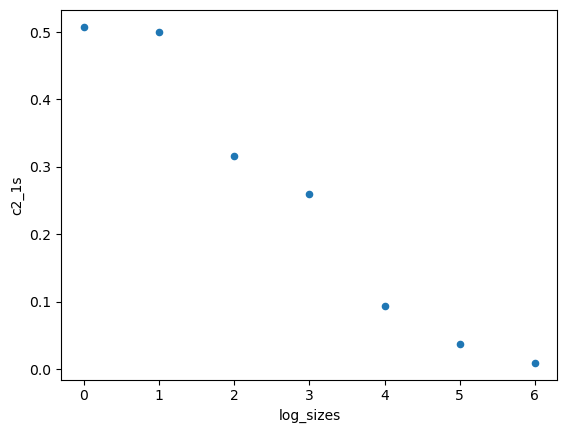

In [177]:
scale_index.plot.scatter('log_sizes', 'c2_1s')

In [79]:
df = scale_index.iloc[0:7]
feature = multifractale_estimation(df)
print(feature['c2_1']**.5, ((feature['c1_1'] - 2*np.log(2))*2)**.5)
print(feature['c2_2']**.5, ((feature['c1_2'] - 2*np.log(2))*2)**.5)

0.3235065476840862 0.3237970485168034
0.33957688348203946 0.32445958762393656
